In [ ]:
import sys
sys.path.insert(0, "/Users/adrianjuarez/Documents/Covert_lab/Repos/mother_machine_cell_tracker")
import mmtrack.mm_cell_segmentation as mm3seg
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from mmtrack import pre_process_mm
from mmtrack import plot_cells
import warnings
import networkx as nx
import tifffile
from skimage.filters import threshold_otsu
import skimage.segmentation as segmentation
from skimage import segmentation, morphology, measure, filters
import scipy.ndimage as ndi
from skimage.filters import threshold_local
import json
import pandas as pd

In [2]:
def get_tiff_frame_count(file_path):
	"""Reads a TIFF file and returns the index of the last time frame (T - 1)."""
	try:
		# 1. Read the image data into a NumPy array
		img_stack = tifffile.imread(file_path)

		# 2. Get the shape of the array
		shape = img_stack.shape

		# 3. Assume the time axis (T) is the first dimension
		if len(shape) >= 3:
			# The last index is T - 1, which is shape[0] - 1
			last_frame_index = shape[0] - 1
			return last_frame_index
		else:
			# Handle case where the file might be a single 2D image (T=1, last index 0)
			return 0

	except FileNotFoundError:
		print(f"Error: TIFF file not found at {file_path}")
		return 0
	except Exception as e:
		print(f"Error reading TIFF file {file_path}: {e}")
		return 0
	
def overlap(bbox1, bbox2):
    """Checks if two bounding boxes overlap."""
    x1 = max(bbox1[0], bbox2[0])
    y1 = max(bbox1[1], bbox2[1])
    x2 = min(bbox1[2], bbox2[2])
    y2 = min(bbox1[3], bbox2[3])
    return x1 < x2 and y1 < y2

In [4]:
def segment_chnl_stack(path_to_phase_channel_stack,
					   output_path,
					   OTSU_threshold=1.5,
					   first_opening=5,
					   distance_threshold=3,
					   second_opening_size=1,
					   min_cell_area=200,
					   max_cell_area=700,
					   small_merge_area_threshold=50,
					   first_opening_morph=None,
					   second_opening_morph=None):
	"""
	For a given fov and peak (channel), do segmentation for all images in the
	subtracted .tif stack.
	Adapted from napari-mm3
	"""

	path_to_mm3_seg = os.path.join(output_path, 'mm3_segmentation')
	os.makedirs(path_to_mm3_seg, exist_ok=True)

	save_to_path = os.path.dirname(path_to_phase_channel_stack)
	filename = os.path.basename(path_to_phase_channel_stack)
	phase_stack = tifffile.imread(path_to_phase_channel_stack)


	# image by image for debug
	segmented_imgs = []
	for time in range(phase_stack.shape[0]):
		unstacked_seg_image = segment_image(phase_stack[time, :, :],
											OTSU_threshold,
											first_opening,
											distance_threshold,
											second_opening_size,
											min_cell_area,
											max_cell_area,
											small_merge_area_threshold,
											first_opening_morph,
											second_opening_morph)

		unstacked_seg_image = unstacked_seg_image.astype("uint8")
		unstacked_seg_filename = f'mask_t_{time:03d}_{filename}'
		unstacked_path = os.path.join(path_to_mm3_seg, unstacked_seg_filename)
		tifffile.imwrite(unstacked_path, unstacked_seg_image)

		segmented_imgs.append(unstacked_seg_image)

	# stack them up along a time axis
	segmented_imgs = np.stack(segmented_imgs, axis=0)


	seg_filename = f'mm3_segmented_{filename}'
	path = os.path.join(save_to_path, seg_filename)
	tifffile.imwrite(path, segmented_imgs)


def segment_image(image,
				  OTSU_threshold=1.5,
				  first_opening=5,
				  distance_threshold=3,
				  second_opening_size=1,
				  min_cell_area=200,
				  max_cell_area=700,
				  small_merge_area_threshold=50,
				  min_axis_ratio=0.04,
				  first_opening_morph=None,
				  second_opening_morph=None):
	"""Segments an image with size and shape filtering, and improved structure."""
	
	scale = np.median(image) / np.mean(image)
	image = image.astype(np.float32)
	image = (image - np.percentile(image, 1)) / (
		np.percentile(image, 99) - np.percentile(image, 1)
	)
	image = np.clip(image, 0, 1)

	# 1. Thresholding and Initial Morphological Operations
	try:
		with warnings.catch_warnings():
			warnings.simplefilter("ignore")
			thresh = filters.threshold_otsu(image)
		thresholded = image > OTSU_threshold * thresh
		
		if first_opening_morph == 1:
			# Use diagonal opening
			diagonal_footprint = np.zeros((first_opening, first_opening))
			np.fill_diagonal(diagonal_footprint, 1)
			morph = morphology.binary_opening(thresholded, diagonal_footprint)
		else:
			# Use disk opening (default when first_opening_morph is 0 or None)
			morph = morphology.binary_opening(thresholded, morphology.disk(first_opening))

		if np.amax(morph) == 0:
			return np.zeros_like(image)

		distance = ndi.distance_transform_edt(morph)
		distance_thresh = distance >= distance_threshold

		#if using spherical opening
		if second_opening_morph == 1:
			# Use diagonal opening
			diagonal_footprint_two = np.zeros((second_opening_size, second_opening_size))
			np.fill_diagonal(diagonal_footprint_two, 1)
			distance_opened = morphology.binary_opening(distance_thresh, diagonal_footprint_two)
		else:
			# Use disk opening (default when second_opening_morph is 0 or None)
			distance_opened = morphology.binary_opening(distance_thresh, morphology.disk(second_opening_size))
			
		labeled, num_labels = morphology.label(distance_opened, connectivity=1, return_num=True)
		if num_labels == 0:
			return np.zeros_like(image)

		markers = morphology.label(labeled, connectivity=1)
		markers = markers.astype(np.int32)
		if np.amax(markers) == 0:
			return np.zeros_like(image)

	except Exception as e:
		print(f"Error in initial processing: {e}")
		return np.zeros_like(image)
		
	
	# 2. Watershed Segmentation
	thresholded_watershed = thresholded
	image_float = image.astype(np.float64)
	try:
		markers[thresholded_watershed == 0] = -1
		with warnings.catch_warnings():
			warnings.simplefilter("ignore")
			labeled_image = segmentation.random_walker(-1 * image_float, markers)
		labeled_image[labeled_image == -1] = 0
	except Exception as e:
		print(f"Error in watershed segmentation: {e}")
		return np.zeros_like(image)

	# 3. Bounding Box Merging (Small Regions)
	regions = measure.regionprops(labeled_image)
	if regions:
		bboxes = np.array([region.bbox for region in regions])
		areas = np.array([region.area for region in regions])
		graph = nx.Graph()

		for i, bbox1 in enumerate(bboxes):
			for j, bbox2 in enumerate(bboxes):
				if i != j and overlap(bbox1, bbox2) and areas[i] < small_merge_area_threshold and areas[j] < small_merge_area_threshold:
					graph.add_edge(regions[i].label, regions[j].label)

		for component in nx.connected_components(graph):
			if len(component) > 1:
				merged_mask = np.isin(labeled_image, list(component))
				new_label = np.max(labeled_image) + 1
				labeled_image[merged_mask] = new_label
				for label in component:
					labeled_image[labeled_image == label] = 0

		labeled_image, _ = morphology.label(labeled_image, connectivity=1, return_num=True)

	# 4. Shape Filtering (Axis Ratio)
	filtered_labeled_image = np.zeros_like(labeled_image)
	regions = measure.regionprops(labeled_image)

	for region in regions:
		if region.axis_major_length > 0:
			axis_ratio = region.axis_minor_length / region.axis_major_length
			if (axis_ratio > min_axis_ratio) | (region.axis_minor_length > 3.5):
				filtered_labeled_image[region.coords[:, 0], region.coords[:, 1]] = region.label

	labeled_image = filtered_labeled_image

	# 5. Size Filtering (Area)
	if min_cell_area is not None or max_cell_area is not None:
		filtered_labeled_image = np.zeros_like(labeled_image)
		regions = measure.regionprops(labeled_image)
		for region in regions:
			area = region.area
			if (min_cell_area is None or area >= min_cell_area) and (max_cell_area is None or area <= max_cell_area):
				filtered_labeled_image[region.coords[:, 0], region.coords[:, 1]] = region.label
		labeled_image = filtered_labeled_image

	return labeled_image

In [5]:
# new function definition

def segment_chnl_stack(path_to_phase_channel_stack,
					   output_path,
					   OTSU_threshold=1.5,
					   first_opening=5,
					   distance_threshold=3,
					   second_opening_size=1,
					   min_cell_area=200,
					   max_cell_area=700,
					   small_merge_area_threshold=50,
					   seg_params=None,
					   first_opening_morph=None,
					   second_opening_morph=None):
	"""
	For a given fov and peak (channel), do segmentation for all images in the
	subtracted .tif stack.
	Adapted from napari-mm3
	"""

	path_to_mm3_seg = os.path.join(output_path, 'mm3_segmentation')
	os.makedirs(path_to_mm3_seg, exist_ok=True)

	save_to_path = os.path.dirname(path_to_phase_channel_stack)
	filename = os.path.basename(path_to_phase_channel_stack)
	phase_stack = tifffile.imread(path_to_phase_channel_stack)

	min_axis_ratio = 0.04

	# image by image for debug
	segmented_imgs = []
	for time in range(phase_stack.shape[0]):
		if seg_params is not None:
			# Find which row's range contains the current time
			for idx, row in seg_params.iterrows():
				if time in row['range']:
					unstacked_seg_image = segment_image(phase_stack[time, :, :],
														row['OTSU_threshold'],
														row['first_opening'],
														row['distance_threshold'],
														row['second_opening_size'],
														row['min_cell_area'],
														row['max_cell_area'],
														row['small_merge_area_threshold'],
														row['min_axis_ratio'],
														row['first_opening_morph'],
														row['second_opening_morph'])

					unstacked_seg_image = unstacked_seg_image.astype("uint8")
					unstacked_seg_filename = f'mask_t_{time:03d}_{filename}'
					unstacked_path = os.path.join(path_to_mm3_seg, unstacked_seg_filename)
					tifffile.imwrite(unstacked_path, unstacked_seg_image)
					segmented_imgs.append(unstacked_seg_image)
					break  # Found the matching range, exit inner loop
		else:
			unstacked_seg_image = segment_image(phase_stack[time, :, :],
												OTSU_threshold,
												first_opening,
												distance_threshold,
												second_opening_size,
												min_cell_area,
												max_cell_area,
												small_merge_area_threshold,
												min_axis_ratio,
												first_opening_morph,
												second_opening_morph)
			unstacked_seg_image = unstacked_seg_image.astype("uint8")
			unstacked_seg_filename = f'mask_t_{time:03d}_{filename}'
			unstacked_path = os.path.join(path_to_mm3_seg, unstacked_seg_filename)
			tifffile.imwrite(unstacked_path, unstacked_seg_image)
			segmented_imgs.append(unstacked_seg_image)

	# stack them up along a time axis
	segmented_imgs = np.stack(segmented_imgs, axis=0)

	seg_filename = f'mm3_segmented_{filename}'
	path = os.path.join(save_to_path, seg_filename)
	tifffile.imwrite(path, segmented_imgs)

In [6]:
col_names = ['segmentation','range','OTSU_threshold',
             'first_opening',
             'distance_threshold',
             'second_opening_size',
             'min_cell_area',
             'max_cell_area',
             'small_merge_area_threshold',
             'min_axis_ratio',
             'first_opening_morph',
             'second_opening_morph']

seg_params = pd.DataFrame(columns=col_names)

row_dict_0 = {
    'segmentation': 0,
    'range': range(0, 66),  # Changed from 65 to 66 to include timepoint 65
    'OTSU_threshold': 1.6,
    'first_opening': 3,
    'distance_threshold': 1.2,
    'second_opening_size': 1,
    'min_cell_area': 50,
    'max_cell_area': 1000,
    'small_merge_area_threshold': 100,
    'min_axis_ratio': 0.04,
    'first_opening_morph': 1,
    'second_opening_morph': 1
}

row_dict_1 = {
    'segmentation': 1,
    'range': range(66, 90),
    'OTSU_threshold': 1.3,
    'first_opening': 2,
    'distance_threshold': 1.2,
    'second_opening_size': 1,
    'min_cell_area': 50,
    'max_cell_area': 1000,
    'small_merge_area_threshold': 100,
    'min_axis_ratio': 0.04,
    'first_opening_morph': 1,
    'second_opening_morph': 1
}

# Add rows using concat
seg_params = pd.concat([seg_params, pd.DataFrame([row_dict_0])], ignore_index=True)
seg_params = pd.concat([seg_params, pd.DataFrame([row_dict_1])], ignore_index=True)

/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykernel_6856/278038735.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  seg_params = pd.concat([seg_params, pd.DataFrame([row_dict_0])], ignore_index=True)


In [7]:
file_name = "/Users/adrianjuarez/Documents/Covert_lab/projects/operon/image_analysis"
folder = 'DUMM_gitg068_baeS_100225_copy'
base_dir = file_name
exp_dict_full_018 ='{"DUMM_gitg068_baeS_100225_copy": {"018": ["1185"]}}'
seg_FOV_dict = json.loads(exp_dict_full_018)

start_frame=0
end_frame = 90 

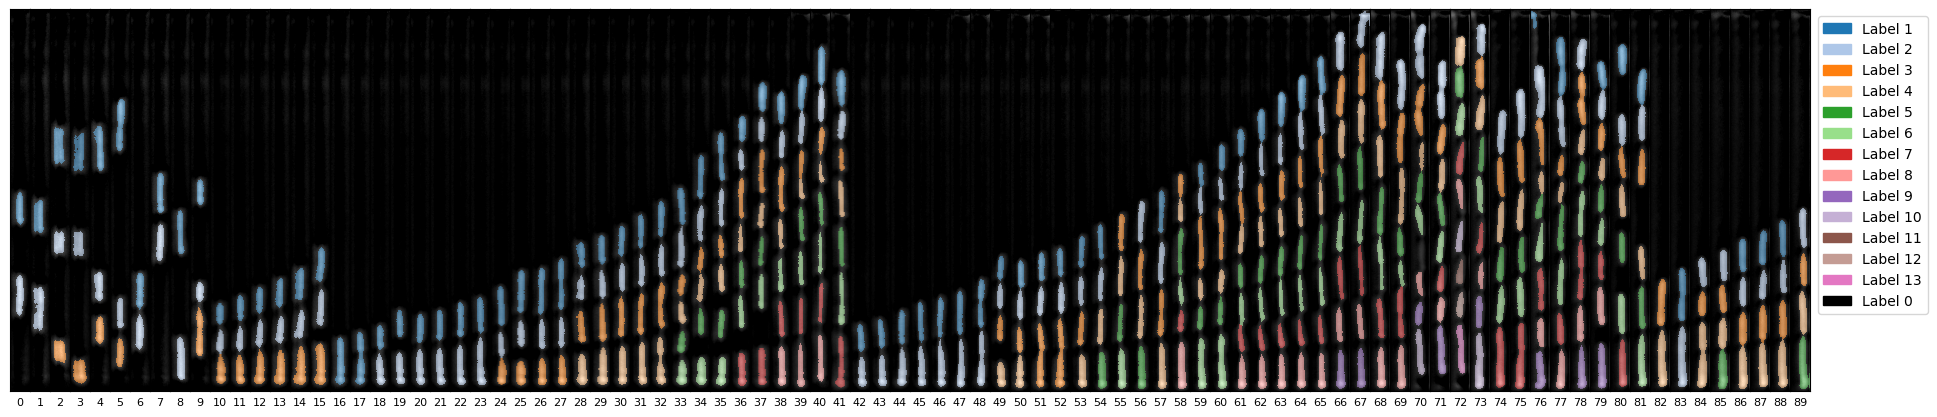

In [8]:
#previous troubhleshooting setup
phase_channel = '0'
fluor_channel = '1'
for folder, fov_dict in seg_FOV_dict.items():
    for fov_id in fov_dict.keys():
        ana_peak_ids = fov_dict[fov_id]
        for peak_id in ana_peak_ids:
            current_end_frame = end_frame
            path_to_phase_stack = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_channel}.tif'
            if current_end_frame is None:
                current_end_frame = get_tiff_frame_count(path_to_phase_stack)
            path_to_fluor_stack = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_{fov_id}_region_{peak_id}_c_{fluor_channel}.tif'
            output_path = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/outputs'
            labeled_stack = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/mm3_segmented_subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_channel}.tif'
            segment_chnl_stack(
                   path_to_phase_stack,
                   output_path,
                   OTSU_threshold=1.5,
                   first_opening=2,
                   distance_threshold=2.1,
                   second_opening_size=2,
                   min_cell_area=90,
				   max_cell_area=1000,
                   small_merge_area_threshold=200,
                   seg_params=seg_params,
                   first_opening_morph=None,
                   second_opening_morph=None,
                   )
            plot_cells.display_segmentation(path_to_phase_stack, mask_path = labeled_stack, start=0, end=90, alpha=0.5)
            # plot_cells.display_segmentation(path_to_phase_stack, mask_path = labeled_stack, start=34, end=35, alpha=0.5)